In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [77]:
data = pd.read_excel('/content/SuperStore Sales DataSet.xlsx')


In [78]:
data.head(5)

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN


In [79]:
row , col = data.shape
print(f"Rows: {row} and Columns: {col}")

Rows: 5901 and Columns: 23


In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID+O6G3A1:R6  5901 non-null   int64         
 1   Order ID          5901 non-null   object        
 2   Order Date        5901 non-null   datetime64[ns]
 3   Ship Date         5901 non-null   datetime64[ns]
 4   Ship Mode         5901 non-null   object        
 5   Customer ID       5901 non-null   object        
 6   Customer Name     5901 non-null   object        
 7   Segment           5901 non-null   object        
 8   Country           5901 non-null   object        
 9   City              5901 non-null   object        
 10  State             5901 non-null   object        
 11  Region            5901 non-null   object        
 12  Product ID        5901 non-null   object        
 13  Category          5901 non-null   object        
 14  Sub-Category      5901 n

In [81]:
data.describe()

,Row ID+O6G3A1:R6,Order Date,Ship Date,Sales,Quantity,Profit,Returns,ind1,ind2
count,5901.000000,5901,5901,5901.000000,5901.000000,5901.000000,287.0,0.0,0.0
mean,5022.422471,2020-02-29 01:53:57.620742144,2020-03-04 00:08:47.097102336,265.345589,3.781901,29.700408,1.0,NaN,NaN
min,1.000000,2019-01-01 00:00:00,2019-01-05 00:00:00,0.836000,1.000000,-6599.978000,1.0,NaN,NaN
25%,2486.000000,2019-09-11 00:00:00,2019-09-15 00:00:00,71.976000,2.000000,1.795500,1.0,NaN,NaN
50%,5091.000000,2020-03-16 00:00:00,2020-03-19 00:00:00,128.648000,3.000000,8.502500,1.0,NaN,NaN
75%,7456.000000,2020-09-14 00:00:00,2020-09-16 00:00:00,265.170000,5.000000,28.615000,1.0,NaN,NaN
max,9994.000000,2020-12-31 00:00:00,2021-01-05 00:00:00,9099.930000,14.000000,8399.976000,1.0,NaN,NaN
std,2877.977184,NaN,NaN,474.260645,2.212917,259.589138,0.0,NaN,NaN


In [82]:
data.isnull().sum()

,0
Row ID+O6G3A1:R6,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [83]:
data.drop(columns=['ind1','ind2'],inplace=True)

In [84]:
data['Returns']=data['Returns'].fillna(0)

In [85]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
5896,False
5897,False
5898,False
5899,False


In [86]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.strftime('%B')
data['Profit Margin (%)'] = (data['Profit'] / data['Sales']) * 100

In [87]:
data.head(5)

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,Year,Month,Profit Margin (%)
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,0.0,Online,2019,January,38.229375
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,0.0,Online,2019,January,22.000000
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Phones,GE 30522EE2,231.98,2,67.2742,0.0,Cards,2019,January,29.000000
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,0.0,Online,2019,January,25.000000
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,0.0,Online,2019,January,-17.500000


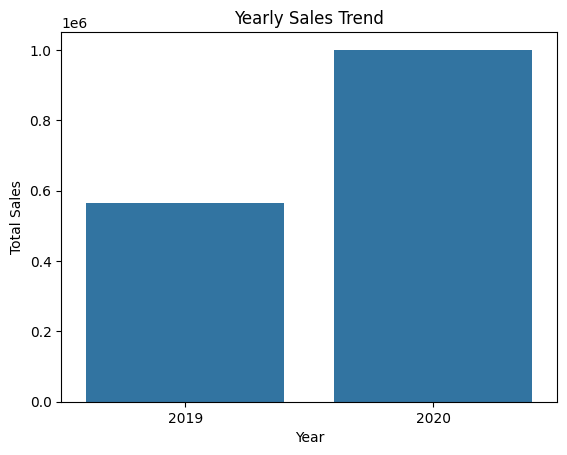

In [88]:
yearly_sales = data.groupby('Year')['Sales'].sum()
sns.barplot(x=yearly_sales.index, y=yearly_sales.values)
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Yearly Sales Trend')
plt.show()

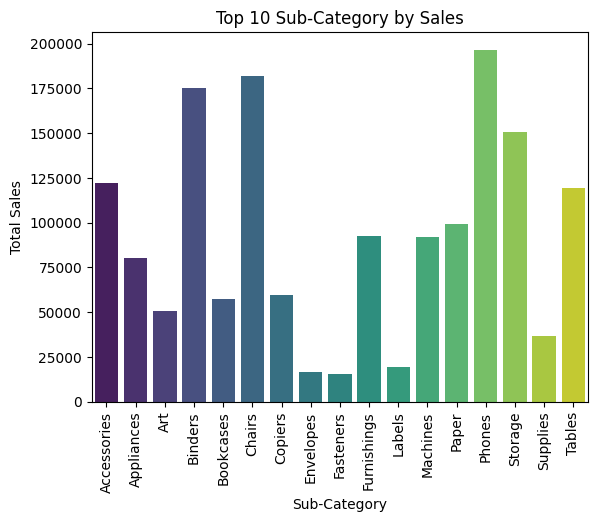

In [89]:
sub_cat=data.groupby('Sub-Category')['Sales'].sum()
sns.barplot(x=sub_cat.index,y=sub_cat.values,palette='viridis')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.title('Top 10 Sub-Category by Sales')
plt.xticks(rotation=90)
plt.show()

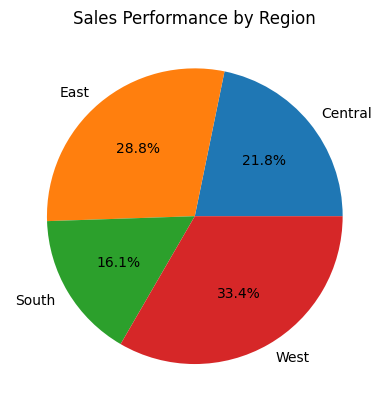

In [93]:
region_perf=data.groupby('Region')['Sales'].sum()
plt.pie(region_perf,labels=region_perf.index,autopct='%1.1f%%')
plt.title('Sales Performance by Region')
plt.show()

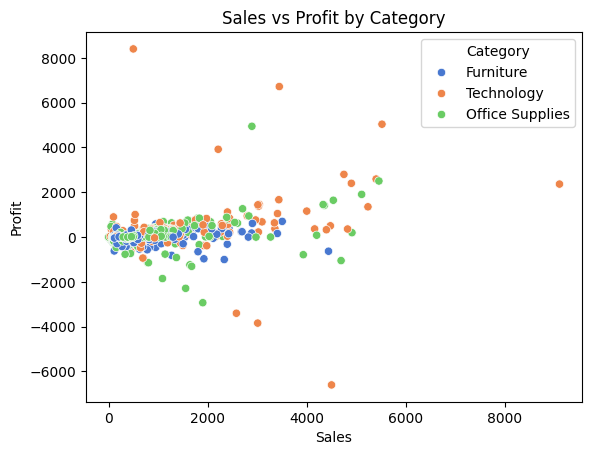

In [99]:
sns.scatterplot(x='Sales',y='Profit',hue='Category',palette='muted',data=data)
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit by Category')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

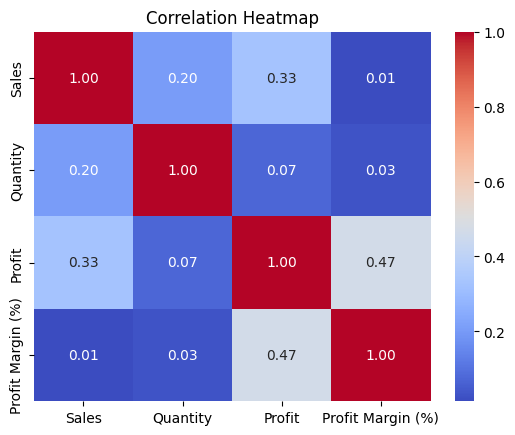

In [103]:
corr_matrix = data[['Sales', 'Quantity', 'Profit', 'Profit Margin (%)']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show